In [1]:
print("Hello World")

Hello World


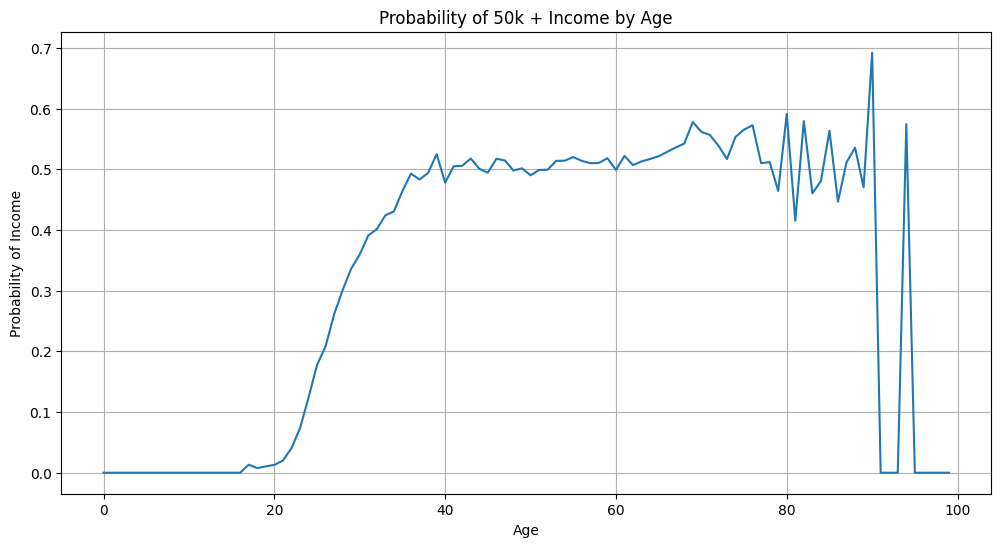

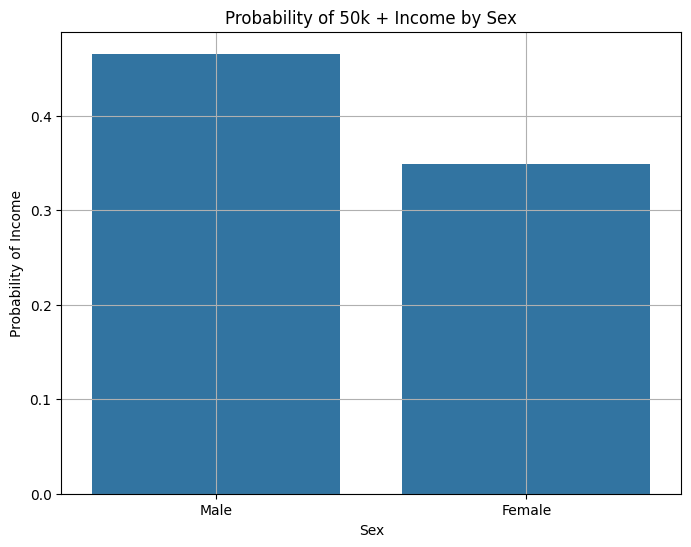

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = pd.read_csv("alt_acsincome_ca_labels_85.csv")
features = pd.read_csv("alt_acsincome_ca_features_85.csv")

df = pd.concat([labels, features], axis=1)
df["PINCP"] = df["PINCP"].map({True: 1, False: 0})

prob_by_sex = df.groupby("SEX")["PINCP"].mean()
sex = np.arange(1, 3)

prob_by_age = df.groupby("AGEP")["PINCP"].mean()
ages = np.arange(0, 100)

plt.figure(figsize=(12, 6))
sns.lineplot(x=ages, y=prob_by_age.reindex(ages, fill_value=0))
plt.title("Probability of 50k + Income by Age")
plt.xlabel("Age")
plt.ylabel("Probability of Income")
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x=sex, y=prob_by_sex.reindex(sex, fill_value=0))
plt.title("Probability of 50k + Income by Sex")
plt.xticks(ticks=[0, 1], labels=["Male", "Female"])
plt.xlabel("Sex")
plt.ylabel("Probability of Income")
plt.grid()
plt.show()

In [3]:
X = features
y = labels["PINCP"].map({True: 1, False: 0})



features_encoded = pd.get_dummies(features,prefix=['COW','SCHL','MAR','OCCP','POBP','RELP','SEX','RAC1P'], columns = ['COW','SCHL','MAR','OCCP','POBP','RELP','SEX','RAC1P'], drop_first=True, dtype=int)

features_encoded.to_csv('alt_acsincome_ca_features_one_hot_encoded.csv', index=False)


| expérimentation1 | train | test |
|------------------|-------|------|
| Taille jeu de données         | (133052, 808) | (33263, 808)|


In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features_encoded, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(133052, 808)
(33263, 808)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_validate
import time

models = [RandomForestClassifier(), AdaBoostClassifier(),  GradientBoostingClassifier()]

for model in models:
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    cross_validation = cross_validate(model, X_train, y_train)
    
    
    print(f"\n{model.__class__.__name__}")
    print(f"Cross Validation Mean Fit time: {np.mean(cross_validation['fit_time']):.2f}s")
    print(f"Train accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Test confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Train confusion matrix:")
    print(confusion_matrix(y_train,  y_pred_train))


RandomForestClassifier
Cross Validation Mean Fit time: 110.19s
Train accuracy: 0.9981
Test accuracy: 0.8130
Test confusion matrix:
[[16676  2918]
 [ 3303 10366]]

AdaBoostClassifier
Cross Validation Mean Fit time: 48.28s
Train accuracy: 0.7781
Test accuracy: 0.7771
Test confusion matrix:
[[16295  3299]
 [ 4116  9553]]

GradientBoostingClassifier
Cross Validation Mean Fit time: 132.02s
Train accuracy: 0.7995
Test accuracy: 0.7986
Test confusion matrix:
[[16547  3047]
 [ 3652 10017]]


| Résultats en entrainement | Random Forest | AdaBoost | XGBoost |
|------------------|-------|------|------|
| Accuracy         |0.998128|0.7781|0.7995| 
| Temps de calcul (sec. )         |110.19s|48.28s|132.02s| 
| Matrice de confusion         |  | | | 

| Résultats en test | Random Forest | AdaBoost | XGBoost |
|------------------|-------|------|------|
| Accuracy         |0.8130|0.7771|0.7986| 
| Matrice de confusion |16676 - 2918<br>3303 - 10366|16295 - 3299<br>4116 - 9553|16547 - 3047<br>3652 - 10017| 